In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sbi.utils import BoxUniform
from torch.distributions import LogNormal, Independent
from joblib import Parallel, delayed
from sbi.analysis import pairplot
from sbi.inference import NPE
from sbi.analysis import plot_summary

_ = torch.manual_seed(42)

_ = np.random.seed(0)

# Define Lotka Volterra Simulator
def lotka_volterra(y, alpha, beta, delta, gamma):
    prey, predator = y
    dprey_dt = alpha * prey - beta * prey * predator
    dpredator_dt = delta * prey * predator - gamma * predator
    return np.asarray([dprey_dt, dpredator_dt])

# Define how populations evolve
def simulate(parameters, observation):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]


    y0 = np.asarray([observation[0, 0], observation[0, 1]])  # Initial populations
    t_span = 200  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

# Extract observed data
def extract_data(url):
    df = pd.read_csv(url, delim_whitespace=True, header=None, index_col=0)
    df.index.name = 'Year'
    df.columns = ['Hare', 'Lynx']
    time_vec = df.index.values
    observation = df[['Hare', 'Lynx']].values
    print(observation.shape)
    n_obs = observation.shape[0]
    sigma_hare = 0.2 * np.std(observation[:, 0])   # 20% of hare std
    sigma_lynx = 0.2 * np.std(observation[:, 1])   # 20% of lynx std
    return time_vec, observation, n_obs, sigma_hare, sigma_lynx

# Plot figures for observed lynx hare populations
def plot_observed_data(time_vec, observation):
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    _ = ax.plot(time_vec, observation)
    _ = ax.legend(["Prey", "Predator"])
    _ = ax.set_xlabel("Time")
    _ = ax.set_ylabel("Population")

# Use mean and max as summary statistics
def summarize_simulation(simulation_result):

    prey_population = simulation_result[:, 0]
    predator_population = simulation_result[:, 1]
    
    summary = [
        np.max(prey_population).item(),
        np.max(predator_population).item(),
        np.mean(prey_population).item(),
        np.mean(predator_population).item()
    ]
    return np.asarray(summary)

# pick out n_obs points to ensure arrays are same size
def downsample_to_n_obs(sim_result, n_obs):
    # pick out n_obs points to ensure arrays are same size
    T = sim_result.shape[0]
    idx = np.linspace(0, T - 1, n_obs).astype(int)
    return sim_result[idx]

# returns data that is same size as observed, adding no noise
def simulate_match_data(parameters, n_obs,observation):
    # returns data that is same size as observed, adding no noise
    full_traj = simulate(parameters,observation)            # (2000, 2)
    return downsample_to_n_obs(full_traj, n_obs)  # (n_obs, 2)

# Returns simulations with gaussian noise added
def simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation):
    latent = simulate_match_data(parameters, n_obs,observation)
    noise = np.random.normal(
        loc=0.0,
        scale=np.array([sigma_hare, sigma_lynx]),  # one sigma per column
        size=latent.shape
    )
    # Column 0 ~ N(0, sigma_hare^2), column 1 ~ N(0, sigma_lynx^2)
    noisy = latent + noise
    return noisy

# Return simulations with poissoin noise added
def simulate_poisson(parameters, n_obs, observation):
    latent = simulate_match_data(parameters, n_obs, observation)
    lam = np.clip(latent, 1e-6, None)
    noisy_counts = np.random.poisson(lam)
    return noisy_counts

# Wrapper function to choose noise
def simulator_distribution(distn, parameters, n_obs, sigma_hare, sigma_lynx, observation):
    if distn == 'none':
        result = simulate_match_data(parameters, n_obs, observation)
    elif distn == 'gaussian':
        result = simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation)
    elif distn == 'poisson':
        result = simulate_poisson(parameters, n_obs, observation)
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    return result

# Define a uniform prior
def define_uniform_prior():
    lower_bound = torch.as_tensor([0.05, 0.01, 0.005, 0.005])
    upper_bound = torch.as_tensor([0.15, 0.03, 0.03, 0.15])
    prior = BoxUniform(low=lower_bound, high=upper_bound)
    return prior

# Define a log-normal prior
def define_logn_prior():
    log_means = torch.log(torch.tensor([
        0.17,   # alpha - 1.6
        0.01,   # beta - 3.2
        0.005,  # delta - 0.6
        0.25    # gamma - 0.56
    ]))

    log_stds = torch.tensor([0.25, 0.25, 0.25, 0.25])

    # Build prior
    base_dist = LogNormal(loc=log_means, scale=log_stds)
    prior_lognormal = Independent(base_dist, 1)
    return prior_lognormal


# Wrapper Function to choose prior distn
def choose_prior_and_generate_theta(distn):
    if distn == 'uniform':
        prior = define_uniform_prior()
    elif distn == 'logn':
        prior = define_logn_prior()
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    
    theta = prior.sample((10_000,))
    return prior, theta

# simulator function
def parallel_simulate(theta,distn, n_obs, sigma_hare, sigma_lynx, observation):
    # Our simulator uses numpy, but prior samples are in PyTorch.
    theta_np = theta.numpy()

    num_workers = 8
    simulation_outputs = Parallel(n_jobs=num_workers)(
        delayed(simulator_distribution)(distn,batch,n_obs, sigma_hare, sigma_lynx, observation)
        for batch in theta_np
    )
    return np.asarray(simulation_outputs)

# generate simulations
def generate_x(theta,distn, n_obs,sigma_hare,sigma_lynx, observation):
    simulation_outputs = parallel_simulate(theta,distn, n_obs,sigma_hare, sigma_lynx, observation)
    x = torch.as_tensor(np.asarray([summarize_simulation(sim) for sim in simulation_outputs]), dtype=torch.float32)
    return x

# plot to check simulated data covers observed data
def plot_checker(x, x_obs):
        _ = pairplot(
        samples=x,
        points=x_obs[None, :],  # `points` needs a batch dimension.
        limits=[[0, 200], [0, 200], [0, 50], [0, 50]],
        figsize=(4, 4),
    )


In [ ]:

# Generate net, stopping after max epochs, choosing or not choosing to 
def train_net_generate_samples(x,theta,x_obs, prior, verbose, max_epoch):
    
    inference = NPE(prior= prior, density_estimator="nsf")
    posterior_net = inference.append_simulations(theta, x).train(max_num_epochs=max_epoch, stop_after_epochs=30)
    posterior = inference.build_posterior(sample_with="mcmc")
    samples = posterior.sample((1_000,), x=x_obs)

    if verbose == True:
        _ = plot_summary(
        inference,
        tags=["training_loss", "validation_loss"],
        figsize=(10, 2),
        )

        print(posterior)
        print("Observation: ", x_obs)

        _ = pairplot(
            samples,
            limits=[[0.05, 0.35], [0.005, 0.02], [0.002, 0.01], [0.11, 0.56]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.005, 0.05], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )
        
    return samples, posterior, inference

# Define main function
def __main__(url, prior_name, noise, max_epoch, verbose):

    time_vec, observation,n_obs, sigma_hare, sigma_lynx = extract_data(url)
    plot_observed_data(time_vec, observation)
    prior,theta = choose_prior_and_generate_theta(prior_name)
    x = generate_x(theta,noise, n_obs, sigma_hare, sigma_lynx)
    x_obs = summarize_simulation(observation)
    plot_checker(x,x_obs)
    samples, posterior, inference = train_net_generate_samples(x,theta,x_obs, prior, verbose = verbose, max_epoch=max_epoch)

    results = {
        "samples": samples,          # posterior samples (1000, 4)
        "posterior": posterior,      # sbi posterior object (if you want to reuse it)
        "inference": inference,      # NPE object
        "prior": prior,
        "theta": theta,              # simulated θ used for training (10000, 4)
        "x": x,                      # simulated summaries (10000, 4)
        "x_obs": x_obs,              # observed summary (4,)
        "time_vec": time_vec,        # years
        "observation": observation,  # raw data (n_obs, 2)
        "prior_name": prior_name,    # 'uniform' or 'logn'
        "noise_model": noise,        # 'none' / 'gaussian' / 'poisson'
        "n_obs": n_obs,
        "sigma_hare": sigma_hare,
        "sigma_lynx": sigma_lynx,
    }

    return results

'''
#results = __main__(url, prior, noise, max_epoch, verbose = False)

#fname = f"results_{prior}_{noise}.pt"
#torch.save(results, fname)

url = 'http://people.whitman.edu/~hundledr/courses/M250F03/LynxHare.txt'
for prior_name in ["uniform", "logn"]:
    for noise in ["none", "gaussian", "poisson"]:
        results = __main__(url, prior_name, noise, max_epoch=150, verbose=False)
        fname = f"results_{prior_name}_{noise}.pt"
        torch.save(results, fname)
'''

'\n#results = __main__(url, prior, noise, max_epoch, verbose = False)\n\n#fname = f"results_{prior}_{noise}.pt"\n#torch.save(results, fname)\n\nurl = \'http://people.whitman.edu/~hundledr/courses/M250F03/LynxHare.txt\'\nfor prior_name in ["uniform", "logn"]:\n    for noise in ["none", "gaussian", "poisson"]:\n        results = __main__(url, prior_name, noise, max_epoch=150, verbose=False)\n        fname = f"results_{prior_name}_{noise}.pt"\n        torch.save(results, fname)\n'

C:\Users\vasir\AppData\Local\Temp\ipykernel_25252\2398613277.py:46: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None, index_col=0)


(91, 2)


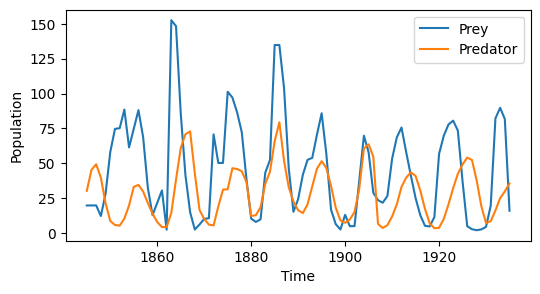

In [16]:
url = 'http://people.whitman.edu/~hundledr/courses/M250F03/LynxHare.txt'
prior_name = 'logn' #prior = 'logn'
noise =   'poisson' #'gaussian' 'none'
max_epoch = 150

time_vec, observation,n_obs, sigma_hare, sigma_lynx = extract_data(url)
plot_observed_data(time_vec, observation)


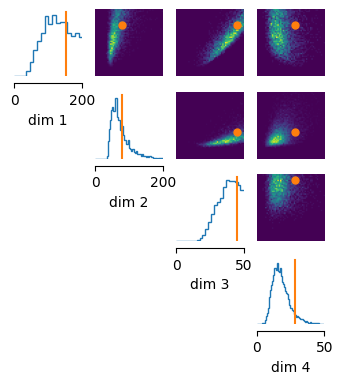

In [33]:
prior,theta = choose_prior_and_generate_theta(prior_name)
x = generate_x(theta,noise, n_obs, sigma_hare, sigma_lynx, observation)
x_obs = summarize_simulation(observation)
plot_checker(x,x_obs)


 Neural network successfully converged after 133 epochs.

c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\sbi\inference\posteriors\mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\vasir\Documents\0 Research Project\Lotka-Volterra\sbi-logs\NPE_C\2025-11-26T01_55_04.525988' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  [152.65        79.35        45.40648352  28.33659341]


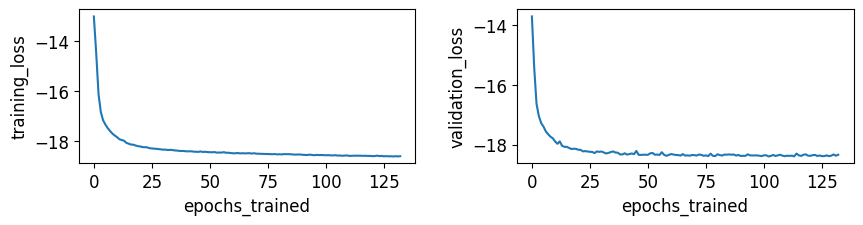

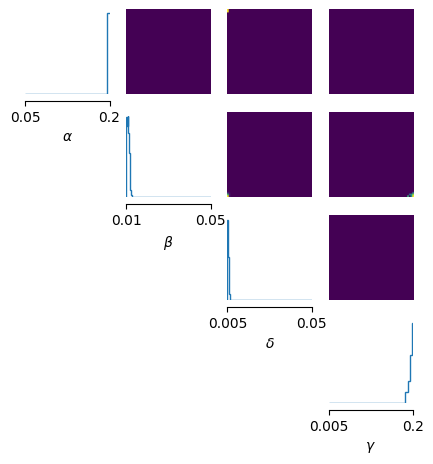

In [35]:
samples, posterior, inference = train_net_generate_samples(x,theta,x_obs, prior, verbose = True, max_epoch=max_epoch)

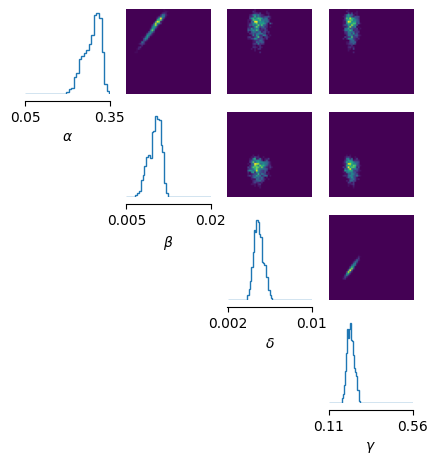

In [37]:
_ = pairplot(
            samples,
            limits=[[0.05, 0.35], [0.005, 0.02], [0.002, 0.01], [0.11, 0.56]],
            ticks=[[0.05, 0.35], [0.005, 0.02], [0.002, 0.01], [0.11, 0.56]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )

In [39]:
results = {
        "samples": samples,          # posterior samples (1000, 4)
        "posterior": posterior,      # sbi posterior object (if you want to reuse it)
        "inference": inference,      # NPE object
        "prior": prior,
        "theta": theta,              # simulated θ used for training (10000, 4)
        "x": x,                      # simulated summaries (10000, 4)
        "x_obs": x_obs,              # observed summary (4,)
        "time_vec": time_vec,        # years
        "observation": observation,  # raw data (n_obs, 2)
        "prior_name": prior_name,    # 'uniform' or 'logn'
        "noise_model": noise,        # 'none' / 'gaussian' / 'poisson'
        "n_obs": n_obs,
        "sigma_hare": sigma_hare,
        "sigma_lynx": sigma_lynx,
    }

fname = f"results_{prior_name}_{noise}.pt"
torch.save(results, fname)

c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\torch\serialization.py:1088: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tensorboard summary writer (instead of appending to the current one).
  pickler.dump(obj)


In [42]:

from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot

def load_results_file(file_name):
    res = torch.load(file_name)
    return res

def posterior_predictive_from_results(res, observation,num_samples=10):
    posterior   = res["posterior"]
    x_obs       = res["x_obs"]
    noise_model = res["noise_model"]
    n_obs       = res["n_obs"]
    sigma_hare  = res["sigma_hare"]
    sigma_lynx  = res["sigma_lynx"]

    samples = posterior.sample((num_samples,), x=x_obs)
    preds = parallel_simulate(samples, noise_model, n_obs, sigma_hare, sigma_lynx, observation)
    return preds

def generate_comparison_plot(res_A, res_B, preds_A, preds_B):
    time_vec    = res_A["time_vec"]      # same for both if you used same data
    observation = res_A["observation"]

    fig, ax = plt.subplots(1, 1, figsize=(14, 7))

    #Labels for Models
    label_A = f"Model A (prior={res_A['prior_name']}, noise={res_A['noise_model']})"
    label_B = f"Model B (prior={res_B['prior_name']}, noise={res_B['noise_model']})"

    # Observed
    ax.plot(time_vec, observation[:, 0], c="k", lw=2, label="Hare (obs)")
    ax.plot(time_vec, observation[:, 1], c="k", lw=2, ls="--", label="Lynx (obs)")

    #Dummy plots for labels
    ax.plot([], [], c="tab:blue",   lw=2, label=f"Hare - {label_A}")
    ax.plot([], [], c="tab:orange", lw=2, label=f"Lynx - {label_A}")
    ax.plot([], [], c="tab:green",  lw=2, label=f"Hare - {label_B}")
    ax.plot([], [], c="tab:red",    lw=2, label=f"Lynx - {label_B}")

    # Model A
    for i in range(preds_A.shape[0]):
        ax.plot(time_vec, preds_A[i, :, 0], c="tab:blue", alpha=0.2, )
        ax.plot(time_vec, preds_A[i, :, 1], c="tab:orange", alpha=0.2)

    # Model B
    for i in range(preds_B.shape[0]):
        ax.plot(time_vec, preds_B[i, :, 0], c="tab:green", alpha=0.2)
        ax.plot(time_vec, preds_B[i, :, 1], c="tab:red", alpha=0.2)

    ax.set_xlabel("Year")
    ax.set_ylabel("Population")
    ax.set_title("Posterior predictive trajectories: Model A vs Model B")
    ax.legend()

def generate_hare_only_comparison(res_A, res_B, preds_A, preds_B):
    time_vec    = res_A["time_vec"]
    observation = res_A["observation"]

    label_A = f"Model A (prior={res_A['prior_name']}, noise={res_A['noise_model']})"
    label_B = f"Model B (prior={res_B['prior_name']}, noise={res_B['noise_model']})"

    fig, ax = plt.subplots(1, 1, figsize=(14,6))

    # Observed hare
    ax.plot(time_vec, observation[:, 0], c="k", lw=3, label="Hare (obs)")

    # Dummy legend handles
    ax.plot([], [], c="tab:blue",  lw=2, label=f"Hare – {label_A}")
    ax.plot([], [], c="tab:green", lw=2, label=f"Hare – {label_B}")

    # Posterior predictive hare trajectories
    for i in range(preds_A.shape[0]):
        ax.plot(time_vec, preds_A[i, :, 0], c="tab:blue", alpha=0.25)

    for i in range(preds_B.shape[0]):
        ax.plot(time_vec, preds_B[i, :, 0], c="tab:green", alpha=0.25)

    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Hare population", fontsize=12)
    ax.set_title("Posterior predictive trajectories (Hare only): Model A vs Model B", fontsize=16)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

def generate_mean_comparison_plot(res_A, res_B, preds_A, preds_B):
   
    time_vec    = res_A["time_vec"]
    observation = res_A["observation"]

    # Build labels
    label_A = f"Model A (prior={res_A['prior_name']}, noise={res_A['noise_model']})"
    label_B = f"Model B (prior={res_B['prior_name']}, noise={res_B['noise_model']})"

    fig, ax = plt.subplots(1, 1, figsize=(14,6))
    
    #plot observed
    ax.plot(time_vec, observation[:, 0], c="k", lw=3, label="Hare (obs)")
    ax.plot(time_vec, observation[:, 1], c="k", lw=3, ls="--", label="Lynx (obs)")

    # Model A means
    mean_hare_A = preds_A[:, :, 0].mean(axis=0)
    mean_lynx_A = preds_A[:, :, 1].mean(axis=0)

    # Model B means
    mean_hare_B = preds_B[:, :, 0].mean(axis=0)
    mean_lynx_B = preds_B[:, :, 1].mean(axis=0)

    # Plot means
    ax.plot(time_vec, mean_hare_A, c="tab:blue", lw=2,
            label=f"Hare - {label_A}")
    ax.plot(time_vec, mean_lynx_A, c="tab:orange", lw=2,
            label=f"Lynx - {label_A}")

    ax.plot(time_vec, mean_hare_B, c="tab:green", lw=2,
            label=f"Hare - {label_B}")
    ax.plot(time_vec, mean_lynx_B, c="tab:red", lw=2,
            label=f"Lynx - {label_B}")

    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Population", fontsize=12)
    ax.set_title("Posterior Predictive MEANS: Model A vs Model B", fontsize=16)
    ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

def generate_hare_mean_comparison(res_A, res_B, preds_A, preds_B):
    
    time_vec    = res_A["time_vec"]
    observation = res_A["observation"]

    # Build labels
    label_A = f"Model A (prior={res_A['prior_name']}, noise={res_A['noise_model']})"
    label_B = f"Model B (prior={res_B['prior_name']}, noise={res_B['noise_model']})"

    fig, ax = plt.subplots(1, 1, figsize=(14,5))

    # Observed hare population
    ax.plot(time_vec, observation[:, 0], c="k", lw=3, label="Hare (obs)")


    # Posterior predictive means
    # preds_A, preds_B: (num_samples, n_obs, 2)
    # Hare means per model
    mean_hare_A = preds_A[:, :, 0].mean(axis=0)
    mean_hare_B = preds_B[:, :, 0].mean(axis=0)

    # Plot means
    ax.plot(
        time_vec, mean_hare_A,
        c="tab:blue", lw=2,
        label=f"{label_A}"
    )

    ax.plot(
        time_vec, mean_hare_B,
        c="tab:green", lw=2,
        label=f"{label_B}"
    )
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Hare population", fontsize=12)
    ax.set_title("Posterior Predictive MEANS (Hare only): Model A vs Model B", fontsize=16)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

def run_sbc_for_model(prior, posterior, noise_model, n_obs, sigma_hare, sigma_lynx, observation,num_sbc_samples=200, num_posterior_samples=1_000):
    
    prior_samples = prior.sample((num_sbc_samples,))
    prior_predictives = parallel_simulate(prior_samples, noise_model, n_obs, sigma_hare, sigma_lynx, observation)
    prior_summary = torch.as_tensor(
        np.asarray([summarize_simulation(sim) for sim in prior_predictives]),
        dtype=torch.float32,
    )
    ranks, _ = run_sbc(
        prior_samples,
        prior_summary,
        posterior,
        reduce_fns=lambda theta, x: -posterior.log_prob(theta, x),
        num_posterior_samples=num_posterior_samples,
        use_batched_sampling=False,
    )
    return ranks

def generate_ranks_A_and_B(res_A,res_B,observation,num_sbc_samples,num_posterior_samples):
    
    prior_A      = res_A["prior"]      
    posterior_A  = res_A["posterior"]
    noise_A      = res_A["noise_model"]
    n_obs_A      = res_A["n_obs"]
    sigma_hare_A = res_A["sigma_hare"]
    sigma_lynx_A = res_A["sigma_lynx"]

    prior_B      = res_B["prior"]
    posterior_B  = res_B["posterior"]
    noise_B      = res_B["noise_model"]
    n_obs_B      = res_B["n_obs"]
    sigma_hare_B = res_B["sigma_hare"]
    sigma_lynx_B = res_B["sigma_lynx"]

    num_sbc_samples     = 200
    num_posterior_samples = 1_000

    # Run SBC for each model
    ranks_A = run_sbc_for_model(
        prior_A, posterior_A, noise_A, n_obs_A, sigma_hare_A, sigma_lynx_A, observation,
        num_sbc_samples=num_sbc_samples,
        num_posterior_samples=num_posterior_samples,
    )

    ranks_B = run_sbc_for_model(
        prior_B, posterior_B, noise_B, n_obs_B, sigma_hare_B, sigma_lynx_B, observation,
        num_sbc_samples=num_sbc_samples,
        num_posterior_samples=num_posterior_samples,
    )
    return ranks_A, ranks_B

def plot_sbc(res_A, res_B, ranks_A, ranks_B, num_posterior_samples):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: Model A
    sbc_rank_plot(
        ranks_A,
        num_posterior_samples,
        plot_type="cdf",
        num_bins=20,
        axes=axes[0],          # <- use this subplot
    )
    axes[0].set_title(
        f"SBC - Model A\n(prior={res_A['prior_name']}, noise={res_A['noise_model']})"
    )

    # Right: Model B
    sbc_rank_plot(
        ranks_B,
        num_posterior_samples,
        plot_type="cdf",
        num_bins=20,
        axes=axes[1],          # <- use second subplot
    )
    axes[1].set_title(
        f"SBC – Model B\n(prior={res_B['prior_name']}, noise={res_B['noise_model']})"
    )

    plt.tight_layout()
    plt.show()



In [43]:
file_A = 'results_logn_gaussian_old.pt'
file_B = 'results_logn_poisson.pt'

res_A = load_results_file(file_A)
res_B = load_results_file(file_B)


C:\Users\vasir\AppData\Local\Temp\ipykernel_25252\4103955088.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res = torch.load(file_name)


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/5020 [00:00<?, ?it/s]

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/5020 [00:00<?, ?it/s]

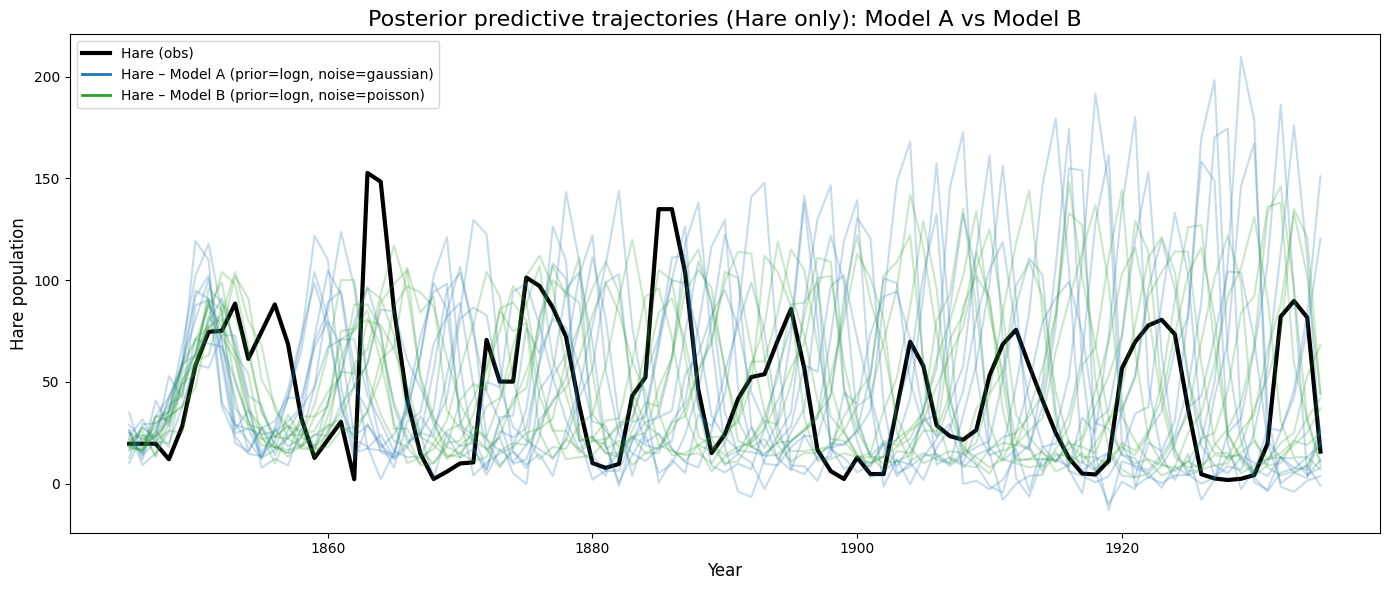

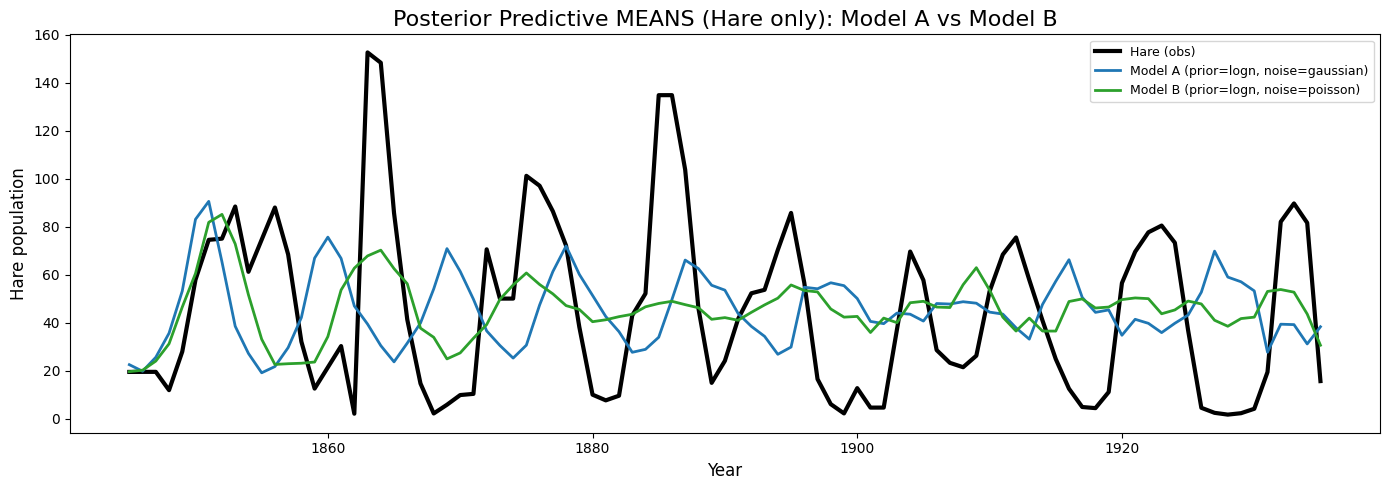

In [44]:

posterior_predictive_A = posterior_predictive_from_results(res_A,observation,num_samples=10 )
posterior_predictive_B = posterior_predictive_from_results(res_B,observation,num_samples=10 )

#generate_comparison_plot(res_A,res_B,posterior_predictive_A,posterior_predictive_B)
generate_hare_only_comparison(res_A,res_B,posterior_predictive_A,posterior_predictive_B)
generate_hare_mean_comparison(res_A,res_B,posterior_predictive_A,posterior_predictive_B)



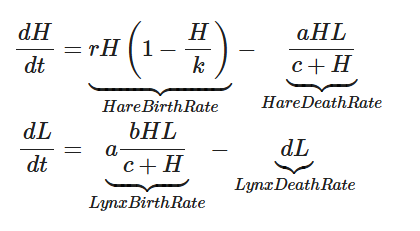
H and L are pop densities

In [ ]:
num_sbc_samples=200
num_posterior_samples = 1000
ranks_A, ranks_B = generate_ranks_A_and_B(res_A,res_B,observation,num_sbc_samples,num_posterior_samples)
plot_sbc(res_A, res_B, ranks_A, ranks_B, num_posterior_samples)

c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\sbi\diagnostics\sbc.py:83: UserWarning: Using non-batched sampling. Depending on the number of different xs ( 200) and the number of parallel workers 1, this might take a lot of time.
  posterior_samples = get_posterior_samples_on_batch(
Sampling 200 times (1000,) posterior samples.:  19%|█▉        | 38/200 [8:40:39<5:48:14, 128.98s/it]   